<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

I0000 00:00:1775684184.738013 1496673 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775684184.738466 1496673 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775684184.772601 1496673 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775684185.710851 1496673 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

### Datos
Utilizaremos como dataset canciones de bandas de habla inglés.

In [2]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

In [4]:
raw_html = urllib.request.urlopen(
    "https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook"
)
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, "lxml")

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all("p")

article_text = ""

for para in article_paragraphs:
    article_text += para.text + " "

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [5]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

' en el año 1872, la casa número 7 de saville-row, burlington gardens \n—donde murió sheridan en 1814— estaba habitada por phileas fogg, quien a\n pesar de que parecía haber tomado el partido de no hacer nada que \npudiese llamar la atención, era uno de los miembros más notables y \nsingulares del reformclub de londres. por consiguiente, phileas fogg, personaje enigmático y del cual sólo \nse sabía que era un hombre muy galante y de los más cumplidos gentlemen \nde la alta sociedad inglesa, sucedía a uno de los más grandes oradores \nque honran a inglaterra. decíase que se daba un aire a lo byron —su cabeza, se entiende, \nporque, en cuanto a los pies, no tenía defecto alguno—, pero a un byron \nde bigote y pastillas, a un byron impasible, que hubiera vivido mil años\n sin envejecer. phileas fogg, era inglés de pura cepa; pero quizás no había nacido en\n londres. jamás se le había visto en la bolsa ni en el banco, ni en \nninguno de los despachos mercantiles de la city. ni las dársenas

In [8]:
# la longitud del corpus es:
len(article_text)

395529

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [ ]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [7]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences  # se utilizará para padding

In [15]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [16]:
# la longitud del vocabulario de caracteres es:
len(chars_vocab)

67

In [17]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v, k in enumerate(chars_vocab)}
idx2char = {v: k for k, v in char2idx.items()}

###  Tokenizar

In [23]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]
len(tokenized_text)

395529

In [20]:
tokenized_text[:1000]

[22,
 6,
 43,
 22,
 6,
 30,
 22,
 54,
 51,
 46,
 22,
 19,
 2,
 58,
 17,
 36,
 22,
 30,
 54,
 22,
 35,
 54,
 55,
 54,
 22,
 43,
 24,
 34,
 6,
 32,
 46,
 22,
 58,
 22,
 4,
 6,
 22,
 55,
 54,
 10,
 9,
 30,
 30,
 6,
 41,
 32,
 46,
 16,
 36,
 22,
 56,
 12,
 32,
 30,
 9,
 43,
 23,
 39,
 46,
 43,
 22,
 23,
 54,
 32,
 4,
 6,
 43,
 55,
 22,
 47,
 66,
 4,
 46,
 43,
 4,
 6,
 22,
 34,
 12,
 32,
 9,
 28,
 22,
 55,
 42,
 6,
 32,
 9,
 4,
 54,
 43,
 22,
 6,
 43,
 22,
 19,
 2,
 19,
 26,
 66,
 22,
 6,
 55,
 39,
 54,
 56,
 54,
 22,
 42,
 54,
 56,
 9,
 39,
 54,
 4,
 54,
 22,
 60,
 46,
 32,
 22,
 60,
 42,
 9,
 30,
 6,
 54,
 55,
 22,
 27,
 46,
 23,
 23,
 36,
 22,
 11,
 12,
 9,
 6,
 43,
 22,
 54,
 47,
 22,
 60,
 6,
 55,
 54,
 32,
 22,
 4,
 6,
 22,
 11,
 12,
 6,
 22,
 60,
 54,
 32,
 6,
 35,
 61,
 54,
 22,
 42,
 54,
 56,
 6,
 32,
 22,
 39,
 46,
 34,
 54,
 4,
 46,
 22,
 6,
 30,
 22,
 60,
 54,
 32,
 39,
 9,
 4,
 46,
 22,
 4,
 6,
 22,
 43,
 46,
 22,
 42,
 54,
 35,
 6,
 32,
 22,
 43,
 54,
 4,
 54,
 22,
 11,
 12,
 

### Organizando y estructurando el dataset

In [24]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text) * p_val / max_context_size))

In [25]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[: -num_val * max_context_size]
val_text = tokenized_text[-num_val * max_context_size :]

In [26]:
tokenized_sentences_val = [
    val_text[init * max_context_size : init * (max_context_size + 1)] for init in range(num_val)
]

In [27]:
tokenized_sentences_train = [
    train_text[init : init + max_context_size]
    for init in range(len(train_text) - max_context_size + 1)
]

In [28]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [29]:
X.shape

(355829, 100)

In [30]:
X[0, :10]

array([22,  6, 43, 22,  6, 30, 22, 54, 51, 46])

In [31]:
y[0, :10]

array([ 6, 43, 22,  6, 30, 22, 54, 51, 46, 22])

In [32]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [61]:
from keras.layers import TimeDistributed, CategoryEncoding, SimpleRNN
from keras.layers import LSTM, GRU, Embedding, Input

📝 A continuación de definen diferentes arquitecturas para poder determinar que configuración genera texto con más coherencia.
- SimpleEmb: modelo de lenguaje con capa de embedding y una capa recurrente simple.
- LSTMEmb: modelo de lenguaje con capa de embedding y una capa LSTM.
- GRUEmb: modelo de lenguaje con capa de embedding y una capa GRU.
- DeepLSTMEmb: modelo de lenguaje con capa de embedding y dos capas LSTM.
- LSTMEmbPre: modelo de lenguaje con capa de embedding pre-entrenada (Word2Vec) y una capa LSTM.

El analisis de los resultados se realizará a través de la métrica de perplejidad y la calidad de las secuencias generadas. Dicho analisis se encontrará al final del notebook.

Además, se definen los siguientes hiperparámetros para el entrenamiento de los modelos demanera de que tengan parametros similares y puedan ser comparados entre sí. Es decir, la calidad de la generación de secuencias se podrá atribuir a la **arquitectura** y no a una configuración de hiperparámetros más favorable.

In [120]:
# hiperparámetros de entrenamiento
epochs = 20
batch_size = 256
embedding_dim = 64
units = 200
dropout = 0.3
recurrent_dropout = 0.1
optimizer = "rmsprop"

In [124]:
# El modelo que se propone como ejemplo consume los índices de los tokens y los
# transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres).
# Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a
# índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

model_example = Sequential(name="SimpleOHE")
model_example.add(Input(shape=(None, 1)))
model_example.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot")))
model_example.add(SimpleRNN(200, return_sequences=True, dropout=0.3, recurrent_dropout=0.1))
model_example.add(Dense(vocab_size, activation="softmax"))
model_example.compile(loss="sparse_categorical_crossentropy", optimizer="rmsprop")

model_example.summary()

Model: "SimpleOHE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_8              │ (None, None, 67)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_27 (SimpleRNN)       │ (None, None, 200)      │        53,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, None, 67)       │        13,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,067 (261.98 KB)

 Trainable params: 67,067 (261.98 KB)

 Non-trainable params: 0 (0.00 B)

In [121]:
model_simple_emb = Sequential(name="SimpleEmb")

model_simple_emb.add(Input(shape=(max_context_size,)))
model_simple_emb.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))
model_simple_emb.add(
    SimpleRNN(
        units=units, return_sequences=True, dropout=dropout, recurrent_dropout=recurrent_dropout
    )
)
model_simple_emb.add(Dense(vocab_size, activation="softmax"))
model_simple_emb.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

model_simple_emb.summary()

Model: "SimpleEmb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_25 (Embedding)        │ (None, 100, 64)        │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_26 (SimpleRNN)       │ (None, 100, 200)       │        53,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 100, 67)        │        13,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,755 (276.39 KB)

 Trainable params: 70,755 (276.39 KB)

 Non-trainable params: 0 (0.00 B)

In [122]:
model_lstm_emb = Sequential(name="LSTMEmb")

model_lstm_emb.add(Input(shape=(max_context_size,)))
model_lstm_emb.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))
model_lstm_emb.add(
    LSTM(units, return_sequences=True, dropout=dropout, recurrent_dropout=recurrent_dropout)
)
model_lstm_emb.add(Dense(vocab_size, activation="softmax"))
model_lstm_emb.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

model_lstm_emb.summary()

Model: "LSTMEmb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_26 (Embedding)        │ (None, 100, 64)        │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 100, 200)       │       212,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 100, 67)        │        13,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,755 (897.48 KB)

 Trainable params: 229,755 (897.48 KB)

 Non-trainable params: 0 (0.00 B)

In [125]:
model_gru_emb = Sequential(name="GRUEmb")

model_gru_emb.add(Input(shape=(max_context_size,)))
model_gru_emb.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))
model_gru_emb.add(
    GRU(units, return_sequences=True, dropout=dropout, recurrent_dropout=recurrent_dropout)
)
model_gru_emb.add(Dense(vocab_size, activation="softmax"))
model_gru_emb.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

model_gru_emb.summary()

Model: "GRUEmb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_28 (Embedding)        │ (None, 100, 64)        │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 100, 200)       │       159,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 100, 67)        │        13,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,355 (692.79 KB)

 Trainable params: 177,355 (692.79 KB)

 Non-trainable params: 0 (0.00 B)

In [126]:
model_deep_lstm_emb = Sequential(name="DeepLSTMEmb")

model_deep_lstm_emb.add(Input(shape=(max_context_size,)))
model_deep_lstm_emb.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))
model_deep_lstm_emb.add(
    LSTM(units=units, return_sequences=True, dropout=dropout, recurrent_dropout=recurrent_dropout)
)
model_deep_lstm_emb.add(
    LSTM(units=units, return_sequences=True, dropout=dropout, recurrent_dropout=recurrent_dropout)
)
model_deep_lstm_emb.add(Dense(units=32, activation="relu"))
model_deep_lstm_emb.add(Dense(units=vocab_size, activation="softmax"))
model_deep_lstm_emb.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

model_deep_lstm_emb.summary()

Model: "DeepLSTMEmb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_29 (Embedding)        │ (None, 100, 64)        │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 100, 200)       │       212,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 100, 200)       │       320,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 100, 32)        │         6,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 100, 67)        │         2,211 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,731 (2.08 MB)

 Trainable params: 545,731 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [127]:
# Se agrupa los modelos en una lista para facilitar su entrenamiento y evaluación posterior.
models = [model_simple_emb, model_lstm_emb, model_gru_emb, model_deep_lstm_emb]


### Metrica de Perplejidad

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [128]:
class PplCallback(keras.callbacks.Callback):
    """
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    """

    def __init__(self, val_data, history_ppl, patience=5):
        # El callback lo inicializamos con secuencias de validación sobre las cuales
        # mediremos la perplejidad
        self.val_data = val_data

        self.target = []
        self.padded = []

        count = 0
        self.info = []
        self.min_score = np.inf
        self.patience_counter = 0
        self.patience = patience

        # nos movemos en todas las secuencias de los datos de validación
        for seq in self.val_data:
            len_seq = len(seq)
            # armamos todas las subsecuencias
            subseq = [seq[:i] for i in range(1, len_seq)]
            self.target.extend([seq[i] for i in range(1, len_seq)])

            if len(subseq) != 0:
                self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding="pre"))

                self.info.append((count, count + len_seq))
                count += len_seq

        self.padded = np.vstack(self.padded)

    def on_epoch_end(self, epoch, logs=None):
        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded, verbose=0)

        # para cada secuencia de validación
        for start, end in self.info:
            # en `probs` iremos guardando las probabilidades de los términos target
            probs = [
                predictions[idx_seq, -1, idx_vocab]
                for idx_seq, idx_vocab in zip(range(start, end), self.target[start:end])
            ]

            # calculamos la perplejidad por medio de logaritmos
            scores.append(np.exp(-np.sum(np.log(probs)) / (end - start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f"\n{self.model.name} mean perplexity: {current_score} \n")

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(f"{self.model.name}.keras")
            print("Saved new model!")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print("Stopping training...")
                self.model.stop_training = True

### Entrenamiento

In [129]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.

histories_ppl = {}

for model in models:
    print(f"Training {model.name} 🏋️...\n")
    history_ppl = []

    hist = model.fit(
        X,
        y,
        epochs=epochs,
        callbacks=[PplCallback(tokenized_sentences_val, history_ppl)],
        batch_size=batch_size,
    )

    histories_ppl[model.name] = history_ppl.copy()
    print(f"Training {model.name}... DONE ✅\n")

Training SimpleEmb 🏋️...

Epoch 1/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 2.2771
SimpleEmb mean perplexity: 5.520283729896932 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 158s 113ms/step - loss: 2.0116
Epoch 2/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 1.7439
SimpleEmb mean perplexity: 5.061686094037167 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 155s 112ms/step - loss: 1.7201
Epoch 3/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 1.6724
SimpleEmb mean perplexity: 4.906693456741759 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 154s 111ms/step - loss: 1.6628
Epoch 4/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 1.6414
SimpleEmb mean perplexity: 4.824567803271531 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 148s 106ms/step - loss: 1.6366
Epoch 5/20
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 1.6235
SimpleEmb mean perplexity: 4.765213415102306 

Saved new model!
1390/1390 ━━━━━━━━━━━━━━━━━━━━ 147s 106ms/step - loss: 1

In [147]:
for name, history in histories_ppl.items():
    print(f"{name} min perplexity: {min(history)}")

SimpleEmb min perplexity: 4.552928702480297
LSTMEmb min perplexity: 5.04637153923209
GRUEmb min perplexity: 4.21514049278298
DeepLSTMEmb min perplexity: 4.711208879039978


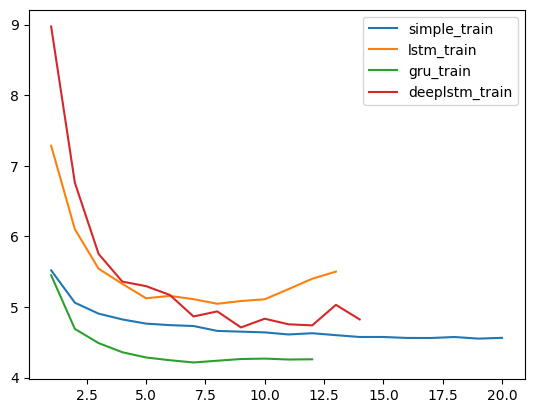

In [ ]:
import seaborn as sns

# Visualizamos la evolución de la perplejidad a lo largo de las épocas para cada modelo.
sns.lineplot(
    x=range(1, len(histories_ppl["SimpleEmb"]) + 1),
    y=histories_ppl["SimpleEmb"],
    label="simple_train",
)
sns.lineplot(
    x=range(1, len(histories_ppl["LSTMEmb"]) + 1), y=histories_ppl["LSTMEmb"], label="lstm_train"
)
sns.lineplot(
    x=range(1, len(histories_ppl["GRUEmb"]) + 1), y=histories_ppl["GRUEmb"], label="gru_train"
)
sns.lineplot(
    x=range(1, len(histories_ppl["DeepLSTMEmb"]) + 1),
    y=histories_ppl["DeepLSTMEmb"],
    label="deeplstm_train",
)
plt.show()

In [ ]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
# model = keras.models.load_model("my_model.keras")


### Predicción del próximo caracter

⚠️ Si se ejecuta desde Colab descomentar comando para instalar Gradio

In [ ]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

#!pip install -q gradio

In [161]:
import gradio as gr

model = np.random.choice(models)


def model_response(human_text):
    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower()]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding="pre")

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0, -1, :])

    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ""
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word


iface = gr.Interface(fn=model_response, inputs=["textbox"], outputs="text")

iface.launch(debug=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Keyboard interruption in main thread... closing server.


## Generación de secuencias

- Greedy search

In [162]:
def generate_seq(model, seed_text, max_length, n_words):
    """
    Exec model sequence prediction

    Args:
        model (keras): modelo entrenado
        seed_text (string): texto de entrada (input_seq)
        max_length (int): máxima longitud de la sequencia de entrada
        n_words (int): números de caracteres a agregar a la sequencia de entrada
    returns:
        output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
    # generate a fixed number of words
    for _ in range(n_words):
        # Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower()]
        # Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding="pre")

        # Predicción softmax
        y_hat = np.argmax(model.predict(encoded, verbose=0)[0, -1, :])
        # Vamos concatenando las predicciones
        out_word = ""

        out_word = idx2char[y_hat]

        # Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [ ]:
# Ejemplo con Greedy Search
input_text = "Los ladrones son"

model = np.random.choice(models)
print(f"Generando texto con el modelo {model.name}...")

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

Generando texto con el modelo SimpleEmb...


'Los ladrones son en el consiguiente a la compa'

- Beam search determinista y muestreo aleatorio

In [179]:
# funcionalidades para hacer encoding y decoding


def encode(text, max_length=max_context_size):
    encoded = [char2idx[ch] for ch in text.lower()]
    encoded = pad_sequences([encoded], maxlen=max_length, padding="pre")

    return encoded


def decode(seq):
    return "".join([idx2char[ch] for ch in seq])

In [157]:
from scipy.special import softmax


# función que selecciona candidatos para el beam search
def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):
    # colectar todas las probabilidades para la siguiente búsqueda
    pred_large = []

    for idx, pp in enumerate(pred):
        pred_large.extend(np.log(pp + 1e-10) + history_probs[idx])

    pred_large = np.array(pred_large)

    # criterio de selección
    if mode == "det":
        idx_select = np.argsort(pred_large)[::-1][:num_beams]  # beam search determinista
    elif mode == "sto":
        idx_select = np.random.choice(
            np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large / temp)
        )  # beam search con muestreo aleatorio
    else:
        raise ValueError(f"Wrong selection mode. {mode} was given. det and sto are supported.")

    # traducir a índices de token en el vocabulario
    new_history_tokens = np.concatenate(
        (np.array(history_tokens)[idx_select // vocab_size], np.array([idx_select % vocab_size]).T),
        axis=1,
    )

    # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
    return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model, num_beams, num_words, input, temp=1, mode="det"):
    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded, verbose=0)[0, -1, :]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates(
        [y_hat], num_beams, vocab_size, history_probs, history_tokens, temp, mode
    )

    # beam search loop
    for i in range(num_words - 1):
        preds = []

        for hist in history_tokens:
            # actualizar secuencia de tokens
            input_update = np.array([hist[i + 1 :]]).copy()

            # predicción
            y_hat = model.predict(input_update, verbose=0)[0, -1, :]

            preds.append(y_hat)

        history_probs, history_tokens = select_candidates(
            preds, num_beams, vocab_size, history_probs, history_tokens, temp, mode
        )

    return history_tokens[:, -(len(input) + num_words) :]

In [ ]:
# predicción con beam search
salidas = beam_search(model, num_beams=10, num_words=50, input="habia una vez", temp=1, mode="sto")
len(salidas)

In [160]:
# veamos las salidas
for i in range(5):
    print(decode(salidas[i]))

habia una vez en la casa de los indios de los soldados de la pr
habia una vez en la casa de los indios de los soldados de la pr
habia una vez en la casa de los indios de los soldados de la to
habia una vez en la casa de los indios de los soldados de la pa
habia una vez en la casa de los indios de los soldados de la cu


---

## Pruebas de generación de secuencias

A partir de un prompt cualquiera y otro más específicos al corpus, se generan secuencias con cada modelo entrenado para poder comparar la calidad de las secuencias generadas. Para esto se utilizan las estrategias de generación de secuencias vistas en clase: Greedy Search, Beam Search determinista y estocástica. En este último caso se agrega el efecto de la temperatura en la generación.

In [184]:
prompts = ["la vuelta al", "phileas fogg", "El tigre se encontro"]

max_length = max_context_size
n_words = 50
num_beams = 5

In [ ]:
# Greedy Search
for model in models:
    print(f"Generando texto con el modelo {model.name}...")
    for prompt in prompts:
        output = generate_seq(model, prompt, max_length=max_length, n_words=n_words)
        print(f"Output: {output}")
    print("---" * 20)

Generando texto con el modelo SimpleEmb...
Output: la vuelta al consiguiente a la compañeros de la compañeros de 
Output: phileas fogg y la compañeros de la compañeros de la compañeros
Output: El tigre se encontro de la compañeros de la compañeros de la compañero
------------------------------------------------------------
Generando texto con el modelo LSTMEmb...
Output: la vuelta al mar de la compañía de la compañía de la compañía 
Output: phileas fogg y el conductor de la compañía de la compañía de l
Output: El tigre se encontro de la compañía de la compañía de la compañía de l
------------------------------------------------------------
Generando texto con el modelo GRUEmb...
Output: la vuelta al 
mar de la compañía de la compañía de la compañía
Output: phileas fogg y su 
parte de la compañía de la compañía de la c
Output: El tigre se encontro de la 
pagoda de la compañía de la compañía de la
------------------------------------------------------------
Generando texto con el modelo 

In [181]:
# Beam Search determinista
for model in models:
    print(f"Generando texto con el modelo {model.name}...")
    for prompt in prompts:
        output = beam_search(
            model, num_beams=num_beams, num_words=n_words, input=prompt, temp=1, mode="det"
        )
        text = decode(output[0])
        print(f"Output: {text}")
    print("---" * 20)

Generando texto con el modelo SimpleEmb...
Output: la vuelta algunos viajeros de la compañeros de los viajeros de
Output: phileas fogg en el pasajeros de la compañeros de los viajeros 
Output: el tigre se encontro de la compañeros de la compañeros de los viajeros
------------------------------------------------------------
Generando texto con el modelo LSTMEmb...
Output: la vuelta al momento de los pasajeros de las compañeros de la 
Output: phileas fogg se había considerablemente estaba entre las compa
Output: el tigre se encontro de los pasajeros de las compañeros de la compañía
------------------------------------------------------------
Generando texto con el modelo GRUEmb...
Output: la vuelta algunos 
mil libras de la estación de la estación de
Output: phileas fogg se había encontraron en la estación de la compañí
Output: el tigre se encontro de la compañía de la estación de los 
pasajeros, 
------------------------------------------------------------
Generando texto con el modelo 

In [182]:
# Beam Search estocástico con diferentes temperaturas
for model in models:
    print(f"Generando texto con el modelo {model.name}...")
    for prompt in prompts:
        output_t02 = beam_search(
            model, num_beams=num_beams, num_words=n_words, input=prompt, temp=0.2, mode="sto"
        )
        output_t1 = beam_search(
            model, num_beams=num_beams, num_words=n_words, input=prompt, temp=1, mode="sto"
        )
        output_t5 = beam_search(
            model, num_beams=num_beams, num_words=n_words, input=prompt, temp=5, mode="sto"
        )
        print(f"Output (temp=0.2): {decode(output_t02[0])}")
        print(f"Output (temp=1): {decode(output_t1[0])}")
        print(f"Output (temp=5): {decode(output_t5[0])}")
        print("")
    print("---" * 20)

Generando texto con el modelo SimpleEmb...
Output (temp=0.2): la vuelta al tren en el consiguiente a la compañeros de la com
Output (temp=1): la vuelta al travesía más que el cual andar de los mar francis
Output (temp=5): la vuelta al perforkiéte—.	)i pag. d troteza. ó vivíliahièío7;
Output (temp=0.2): phileas fogg y la compañeros de la compañeros de la compañeros
Output (temp=1): phileas fogg y la de la compañeros de los especie de los mucha
Output (temp=5): phileas fogg,
¿todxis fvago¿r"cíntemolnasn, res vio. c gasgr m
Output (temp=0.2): el tigre se encontro de la compañeros de la estación de la compañeros 
Output (temp=1): el tigre se encontro de esta la mañana, y del "carnatic", en el viaje 
Output (temp=5): el tigre se encontroul;—? maja sáñacuace dificó, ge ayastoma,— cimer h
------------------------------------------------------------
Generando texto con el modelo LSTMEmb...
Output (temp=0.2): la vuelta al mundo de la marcha de la estación de la compañía 
Output (temp=1): la vue

### Conclusiones

Se entrenaron modelos de lenguaje con diferentes arquitecturas y se comparó su desempeño en términos de perplejidad. Se observó que el modelo con la arquitectura que usa la capa GRU obtuvo la mejor perplejidad, seguido por SimpleRNN, lo que sugiere que los modelos más simples se comportan mejor que los más complejos para el corpus elegido y con tokenización por caracteres. Para el caso de LSTM hubo una tendencia al overfitting, lo que podría dar lugar a un bajo desempeño en la generación. Finalmente, la red con mayor profundidad (DeepLSTM) tampoco logró superar a los modelos más simples, lo que podría deberse a la cantidad de datos disponibles para el entrenamiento pero cabe destacar que su tendencia de perplejidad era a la baja, probablemente con más tiempo de entrenamiento podría haber alcanzado un mejor desempeño.

Para los distintos textos de entrada, ningún modelo logró generar secuencias completamente coherentes, incluso la arquitectura con mejor perplejidad (GRU) tampoco se destacó. La generación con *Greedy Search* fue la que generó peores resultados, dando secuencias con palabras repetidas, por ejemplo `phileas fogg y el conductor de la compañía de la compañía de l`. En cambio, la generación con *Beam Search determinista* y *estocástico* si obtuvieron secuencias más coherentes, aunque no completamente . Para el caso estocástico se observó que la temperatura tiene un impacto significativo en la diversidad de las secuencias generadas, para temperaturas grandes se obtuvieron secuencias más diversas pero menos coherentes, se incluyerón caracteres que rompen por completo el sentido de la oracion, ejemplo `phileas fogg; víosi;o. ayíó?, segúmi totar..—uo?`. En cambio, para temperaturas más bajas se obtuvieron secuencias más coherentes.

Por ultimo se destaca que la comparación entre los modelos se realizó variando la arquitectura pero manteniendo los mismos hiperparámetros. Por lo cual, para un mejor analisis de la calidad de las secuencias generadas, se deberían explorar diferentes configuraciones de hiperparámetros para cada modelo.